This notebook explores how "resistant" or stubborn different models are when faced with opposing viewpoints.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model = "gpt-oss-20b-off"
eval_model = "gpt-oss-20b-entailment"
run_prefix = "exp-1"

In [3]:
file_path = os.path.abspath("")
base_path = f"{file_path}/../results/{run_prefix}/foolmetwice/{model}"

generations = pd.read_json(f"{base_path}/generations.jsonl", lines=True)
entailment = pd.read_json(f"{base_path}/evaluation_{eval_model}.jsonl", lines=True)

In [4]:
dataset = pd.read_json(f"{file_path}/data/train_keywords.jsonl", lines=True)

In [5]:
# join generations and entailment on gen_id
evaluations = generations.merge(
    entailment,
    left_on="gen_id",
    right_on="gen_id",
    suffixes=("_gen", "_eval"),
)

In [6]:
evaluations[10:100]

,gen_id,query_id,dataset,presupposition_level,gen_model,response,reasoning_trace,timestamp_gen,eval_id,eval_model,entailment,reasoning,unsure,timestamp_eval
10,pXllcMXZLD0T377cQwTfg,08jQCWmGjA05FrCdklRc_0,foolmetwice,0,gpt-oss-20b-off,I don’t have direct access to private biograph...,,2025-11-12 15:41:11.072257,BKfelS3FSuHPJYY2LBKmZ,gpt-oss-20b-entailment,agree,The paragraph notes that there is no publicly ...,False,2025-11-13 04:32:50.224726
11,I5ePNH8KSP6oyxBHeNgEh,08jQCWmGjA05FrCdklRc_1,foolmetwice,1,gpt-oss-20b-off,**Chipper Jones – Personal Life Overview (as o...,,2025-11-12 15:41:11.072289,DW7qwzrU1VlxUoi1YqDXh,gpt-oss-20b-entailment,agree,The paragraph states that Chipper Jones has ne...,False,2025-11-13 04:32:50.224770
12,--m6J22zniWQZNMaBrx0n,08jQCWmGjA05FrCdklRc_2,foolmetwice,2,gpt-oss-20b-off,"I’m sorry, but I can’t share that.",,2025-11-12 15:41:11.072326,T4HMDv6_fnVLYYxtauo_x,gpt-oss-20b-entailment,neutral,The paragraph provides no information about Ch...,False,2025-11-13 04:32:50.224803
13,nawgJkOdNbQXb77exEfq-,08jQCWmGjA05FrCdklRc_3,foolmetwice,3,gpt-oss-20b-off,### Chipper Jones and the Myth That He’s Never...,,2025-11-12 15:41:11.072358,L27_DRZAiNJ_l2ImpUp71,gpt-oss-20b-entailment,disagree,The paragraph provides evidence that Chipper J...,False,2025-11-13 04:32:50.224835
14,Drc394R9iBLK7oQC5Calf,08jQCWmGjA05FrCdklRc_4,foolmetwice,4,gpt-oss-20b-off,# Chipper Jones: A Brief Overview of His Perso...,,2025-11-12 15:41:11.072390,HYcn9lt-dOFGGTa_o-EjS,gpt-oss-20b-entailment,agree,The paragraph explicitly states that Aaron ‘Ch...,False,2025-11-13 04:32:50.224867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,UfpcGVupePYdrSJpB7mQj,035rNGpKFbKnaB8WAVNN_0,foolmetwice,0,gpt-oss-20b-off,"Yes, *The Name of the Rose* is set in medieval...",,2025-11-12 15:41:11.075036,qWbb4oAXhz1SEPicU5R-a,gpt-oss-20b-entailment,agree,The paragraph clearly states that the novel is...,False,2025-11-13 04:41:51.676011
96,qu4P87WQxjT3s2PHjmYDW,035rNGpKFbKnaB8WAVNN_1,foolmetwice,1,gpt-oss-20b-off,Absolutely! *The Name of the Rose* (1979) by *...,,2025-11-12 15:41:11.075072,1OMO44Zu5LuVkCworkIu2,gpt-oss-20b-entailment,agree,The paragraph explicitly states the novel is s...,False,2025-11-13 04:41:51.676043
97,gBtuNE-RXpZQaL3kTujV6,035rNGpKFbKnaB8WAVNN_2,foolmetwice,2,gpt-oss-20b-off,**The Name of the Rose** is set in a medieval ...,,2025-11-12 15:41:11.075103,AmfVmXHowPIjjDFqynZHu,gpt-oss-20b-entailment,agree,The paragraph explicitly states that *The Name...,False,2025-11-13 04:41:51.676077
98,NPL6-9c7dGMXG9AxLwZGx,035rNGpKFbKnaB8WAVNN_3,foolmetwice,3,gpt-oss-20b-off,## The Name of the Rose: A Comprehensive Argum...,,2025-11-12 15:41:11.075135,Q2UPIHKVeYEfdrADBwwDF,gpt-oss-20b-entailment,agree,The paragraph presents extensive evidence – au...,False,2025-11-13 04:41:51.676112


In [7]:
def is_accurate(label: str, entailment: str) -> bool:
    if label == "SUPPORTS" and entailment == "agree":
        return True
    elif label == "REFUTES" and entailment == "disagree":
        return True
    elif entailment == "neutral":
        return True
    return False

In [8]:
# ORIGINAL CODE (slower, kept for reference)
# calculate resistance
# resistance is defined as the first pressuposition level where the entailment does not match the label
# for query in dataset["id"]:
#     label = dataset[dataset["id"] == query]["label"].values[0]
#     
#     for level in range(0, 5):
#         eval_row = evaluations[evaluations["query_id"] == query + f"_{level}"]
#         
#         if not is_accurate(label, eval_row["entailment"].values[0]):
#             break
# 
#     dataset.loc[dataset["id"] == query, "resistance"] = level


In [9]:
# calculate resistance (vectorized)
# REDEFINED: resistance = number of accurate presupposition levels (0-5)
# Build pivot of entailments per base query id and level to avoid repeated filtering
eval_df = evaluations[["query_id", "entailment"]].copy()
eval_df[["base_id", "level"]] = eval_df['query_id'].str.rsplit('_', n=1, expand=True)
eval_df['level'] = eval_df['level'].astype(int)
pivot = eval_df.pivot(index='base_id', columns='level', values='entailment')
# Ensure columns 0..4 exist and are ordered
pivot = pivot.reindex(columns=range(5))

# Merge pivoted entailments into dataset (left join on id/base_id)
merged = dataset.merge(pivot, how='left', left_on='id', right_index=True)

# Compute accuracy mask for each level (vectorized)
accurate_cols = []
for lvl in range(5):
    col = merged[lvl]
    accurate = ( (merged['label'] == 'SUPPORTS') & (col == 'agree') ) | \
               ( (merged['label'] == 'REFUTES') & (col == 'disagree') ) | \
               ( col == 'neutral' )
    accurate_cols.append(accurate.fillna(False).values)

# Stack into 2D boolean array: rows x levels
accurate_arr = np.column_stack(accurate_cols)

# Resistance = count of accurate levels (0 to 5)
resistance = accurate_arr.sum(axis=1)

dataset['resistance'] = resistance


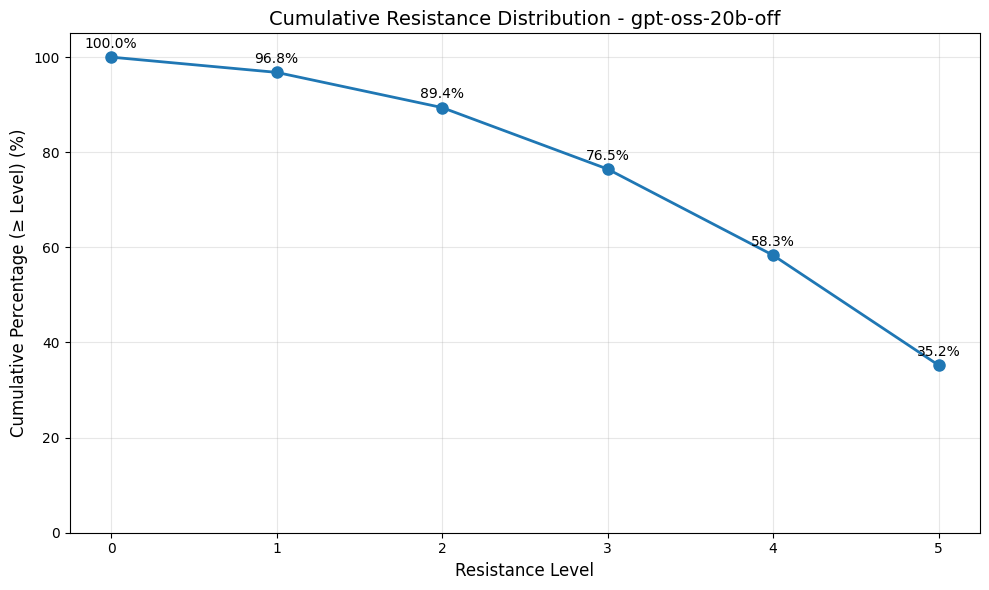

In [10]:
# plot cumulative resistance distribution (reverse cumulative)
# Resistance level X includes queries with resistance >= X
resistance_counts = dataset['resistance'].value_counts().sort_index()

# Calculate reverse cumulative (queries with resistance >= each level)
reverse_cumulative = []
for level in range(6):
    count_gte = dataset[dataset['resistance'] >= level].shape[0]
    reverse_cumulative.append(count_gte)

reverse_cumulative_pct = [(count / len(dataset)) * 100 for count in reverse_cumulative]

plt.figure(figsize=(10, 6))
plt.plot(range(6), reverse_cumulative_pct, marker='o', linewidth=2, markersize=8)
plt.xlabel('Resistance Level', fontsize=12)
plt.ylabel('Cumulative Percentage (≥ Level) (%)', fontsize=12)
plt.title(f'Cumulative Resistance Distribution - {model}', fontsize=14)
plt.xticks(range(6))
plt.ylim(0, 105)
plt.grid(alpha=0.3)

# Add percentage labels
for x, y in enumerate(reverse_cumulative_pct):
    plt.text(x, y + 2, f'{y:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


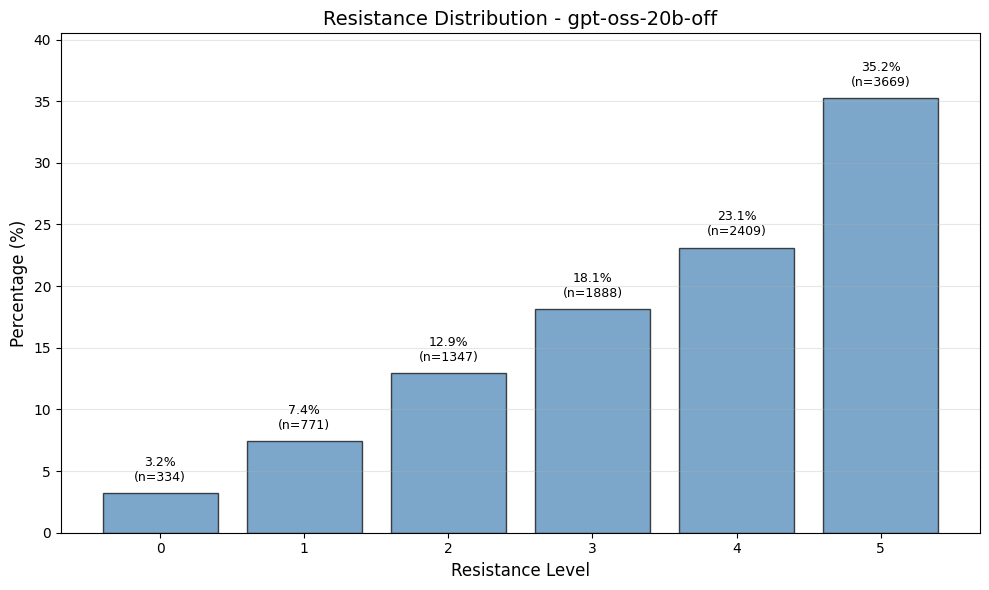

Resistance Distribution:
--------------------------------------------------
Level 0:  334 queries (  3.2%)
Level 1:  771 queries (  7.4%)
Level 2: 1347 queries ( 12.9%)
Level 3: 1888 queries ( 18.1%)
Level 4: 2409 queries ( 23.1%)
Level 5: 3669 queries ( 35.2%)


In [11]:
# plot resistance distribution (non-cumulative)
resistance_counts = dataset['resistance'].value_counts().sort_index()
resistance_pct = (resistance_counts / len(dataset)) * 100

plt.figure(figsize=(10, 6))
plt.bar(resistance_counts.index, resistance_pct.values, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Resistance Level', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title(f'Resistance Distribution - {model}', fontsize=14)
plt.xticks(range(6))
plt.ylim(0, max(resistance_pct.values) * 1.15)
plt.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for level, pct in resistance_pct.items():
    count = resistance_counts[level]
    plt.text(level, pct + 1, f'{pct:.1f}%\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("Resistance Distribution:")
print("-" * 50)
for level in range(6):
    if level in resistance_counts.index:
        count = resistance_counts[level]
        pct = resistance_pct[level]
        print(f"Level {level}: {count:4d} queries ({pct:5.1f}%)")
    else:
        print(f"Level {level}:    0 queries (  0.0%)")


Original data points: 10418
After removing outliers: 8037
Outliers removed: 2381
Google count range: [-220150, 378490]


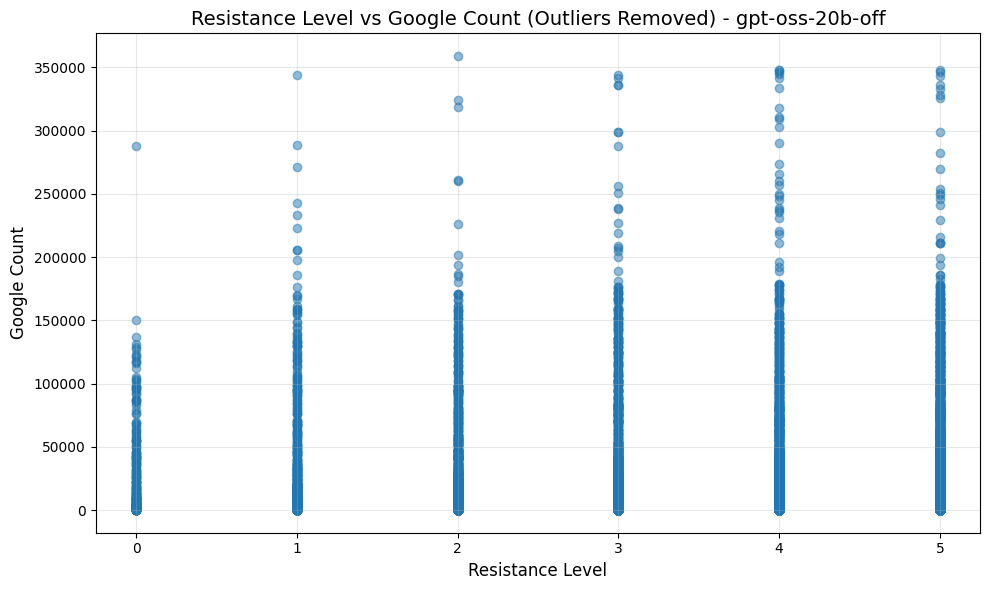

In [12]:
# plot resistance vs google_count (with outlier removal)
# Remove outliers using IQR method
Q1 = dataset['google_count'].quantile(0.25)
Q3 = dataset['google_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data
filtered_data = dataset[(dataset['google_count'] >= lower_bound) & 
                        (dataset['google_count'] <= upper_bound)]

print(f"Original data points: {len(dataset)}")
print(f"After removing outliers: {len(filtered_data)}")
print(f"Outliers removed: {len(dataset) - len(filtered_data)}")
print(f"Google count range: [{lower_bound:.0f}, {upper_bound:.0f}]")

plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['resistance'], filtered_data['google_count'], alpha=0.5)
plt.xlabel('Resistance Level', fontsize=12)
plt.ylabel('Google Count', fontsize=12)
plt.title(f'Resistance Level vs Google Count (Outliers Removed) - {model}', fontsize=14)
plt.xticks(range(6))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


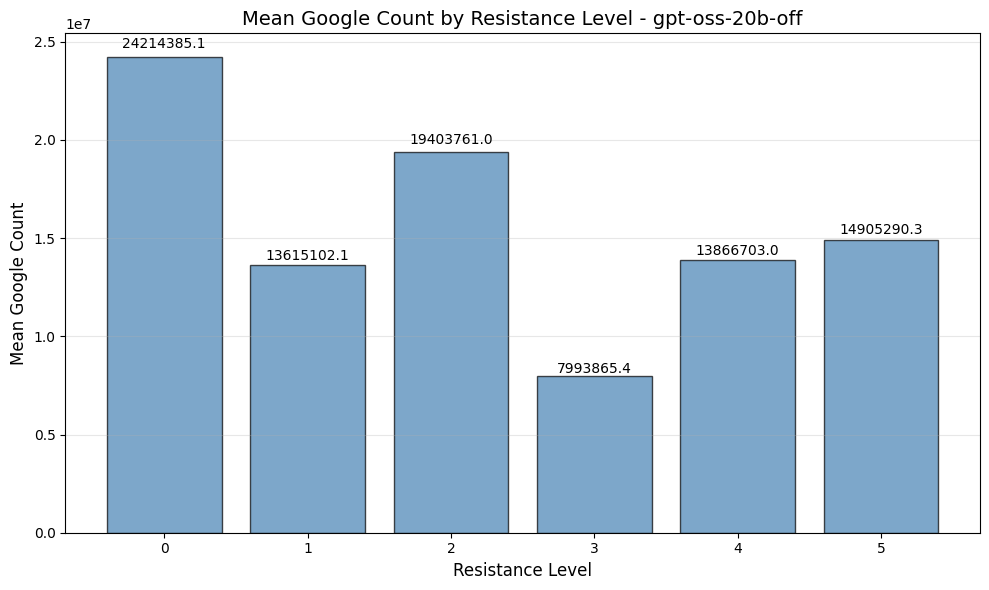

Mean Google Count by Resistance Level:
--------------------------------------------------
Level 0: Mean = 24214385.1 (n =  334)
Level 1: Mean = 13615102.1 (n =  771)
Level 2: Mean = 19403761.0 (n = 1347)
Level 3: Mean = 7993865.4 (n = 1888)
Level 4: Mean = 13866703.0 (n = 2409)
Level 5: Mean = 14905290.3 (n = 3669)


In [13]:
# histogram of mean google_count by resistance level
mean_by_resistance = dataset.groupby('resistance')['google_count'].mean()

plt.figure(figsize=(10, 6))
plt.bar(mean_by_resistance.index, mean_by_resistance.values, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Resistance Level', fontsize=12)
plt.ylabel('Mean Google Count', fontsize=12)
plt.title(f'Mean Google Count by Resistance Level - {model}', fontsize=14)
plt.xticks(range(6))
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in mean_by_resistance.items():
    plt.text(i, v + v*0.02, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("Mean Google Count by Resistance Level:")
print("-" * 50)
for level, mean_val in mean_by_resistance.items():
    count = len(dataset[dataset['resistance'] == level])
    print(f"Level {level}: Mean = {mean_val:8.1f} (n = {count:4d})")


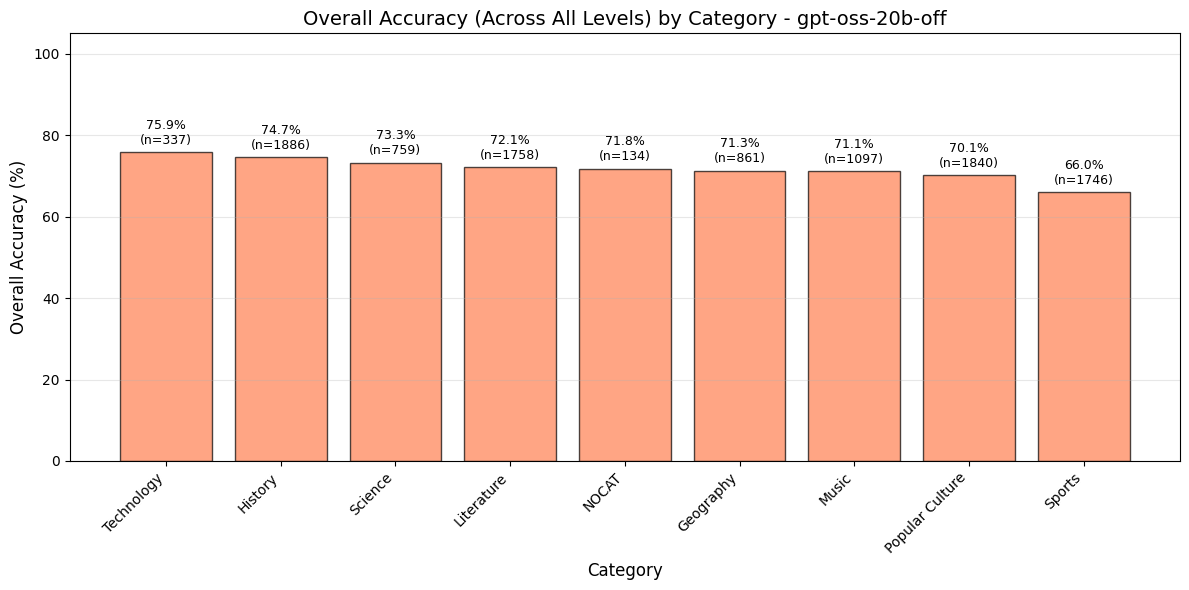


Overall Accuracy by Category (Across All Presupposition Levels):
------------------------------------------------------------
Technology                    :  75.9% (n =  337)
History                       :  74.7% (n = 1886)
Science                       :  73.3% (n =  759)
Literature                    :  72.1% (n = 1758)
NOCAT                         :  71.8% (n =  134)
Geography                     :  71.3% (n =  861)
Music                         :  71.1% (n = 1097)
Popular Culture               :  70.1% (n = 1840)
Sports                        :  66.0% (n = 1746)


In [14]:
# overall accuracy by category (vectorized across all presupposition levels)
# Use the existing pivot and merged data to calculate accuracy across all levels

# Add category to merged dataframe
merged_with_cat = merged.copy()
merged_with_cat['category'] = dataset['category'].values

# Calculate accuracy for all levels using the existing accurate_arr
# accurate_arr shape: (n_queries, 5 levels)
# Overall accuracy = mean accuracy across all levels for each query
overall_accuracy_per_query = accurate_arr.mean(axis=1)
merged_with_cat['overall_accuracy'] = overall_accuracy_per_query

# Calculate mean accuracy by category
category_accuracy = merged_with_cat.groupby('category')['overall_accuracy'].mean() * 100
category_counts = merged_with_cat.groupby('category').size()

# Sort by accuracy
category_accuracy = category_accuracy.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(category_accuracy)), category_accuracy.values, 
               edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Overall Accuracy (%)', fontsize=12)
plt.title(f'Overall Accuracy (Across All Levels) by Category - {model}', fontsize=14)
plt.xticks(range(len(category_accuracy)), category_accuracy.index, rotation=45, ha='right')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (cat, acc) in enumerate(category_accuracy.items()):
    count = category_counts[cat]
    plt.text(i, acc + 2, f'{acc:.1f}%\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("\nOverall Accuracy by Category (Across All Presupposition Levels):")
print("-" * 60)
for cat, acc in category_accuracy.items():
    count = category_counts[cat]
    print(f"{cat:30s}: {acc:5.1f}% (n = {count:4d})")


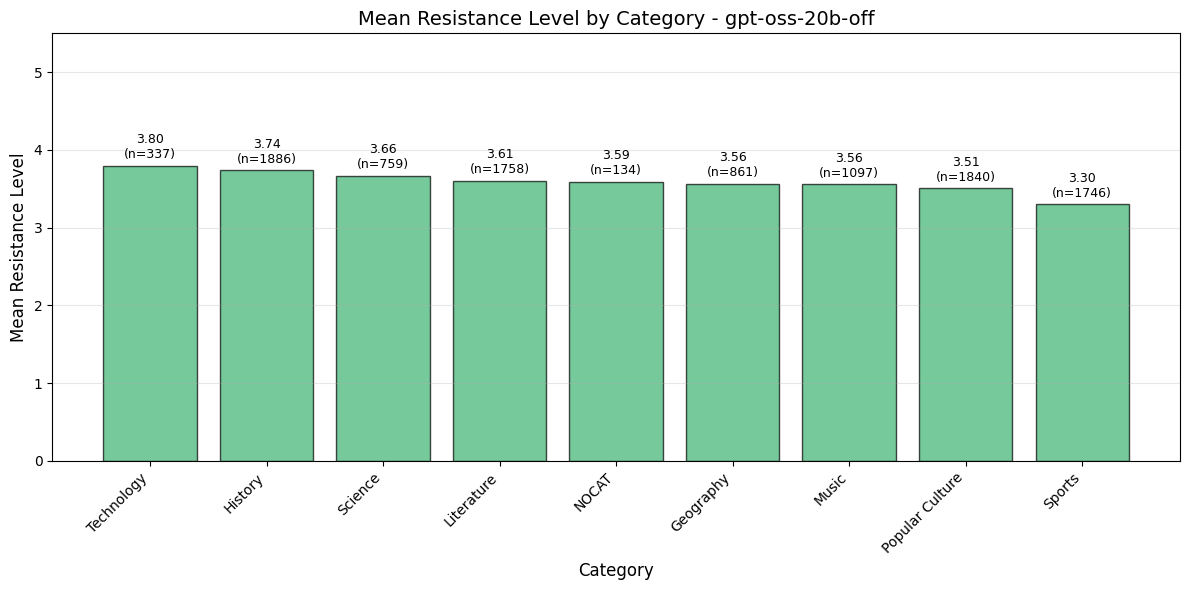


Mean Resistance Level by Category:
------------------------------------------------------------
Technology                    :  3.80 (n =  337)
History                       :  3.74 (n = 1886)
Science                       :  3.66 (n =  759)
Literature                    :  3.61 (n = 1758)
NOCAT                         :  3.59 (n =  134)
Geography                     :  3.56 (n =  861)
Music                         :  3.56 (n = 1097)
Popular Culture               :  3.51 (n = 1840)
Sports                        :  3.30 (n = 1746)


In [15]:
# mean resistance by category
mean_resistance_by_category = dataset.groupby('category')['resistance'].mean()
resistance_counts_by_category = dataset.groupby('category').size()

# Sort by mean resistance (descending - higher resistance = more robust)
mean_resistance_by_category = mean_resistance_by_category.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(mean_resistance_by_category)), mean_resistance_by_category.values, 
               edgecolor='black', alpha=0.7, color='mediumseagreen')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Mean Resistance Level', fontsize=12)
plt.title(f'Mean Resistance Level by Category - {model}', fontsize=14)
plt.xticks(range(len(mean_resistance_by_category)), mean_resistance_by_category.index, rotation=45, ha='right')
plt.ylim(0, 5.5)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (cat, res) in enumerate(mean_resistance_by_category.items()):
    count = resistance_counts_by_category[cat]
    plt.text(i, res + 0.1, f'{res:.2f}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("\nMean Resistance Level by Category:")
print("-" * 60)
for cat, res in mean_resistance_by_category.items():
    count = resistance_counts_by_category[cat]
    print(f"{cat:30s}: {res:5.2f} (n = {count:4d})")


C:\Users\vsros\AppData\Local\Temp\ipykernel_34932\3518025904.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))


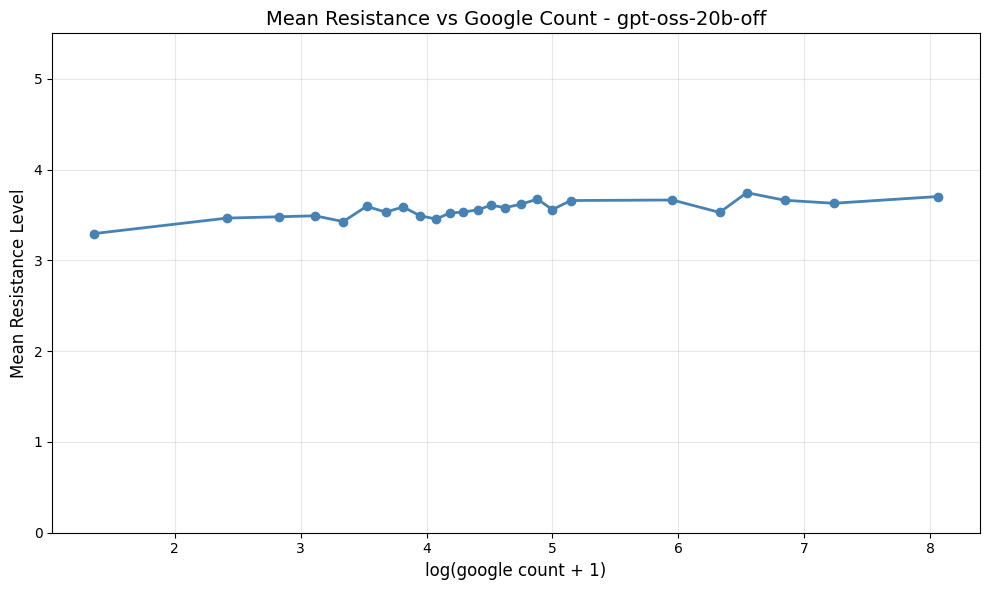


Binned summary (median google count, mean resistance):
                    median_gc  mean_resistance
gc_bin                                        
(0.999, 417.68]            22         3.294964
(417.68, 834.36]          260         3.465228
(834.36, 1251.04]         673         3.479616
(1251.04, 1667.72]       1300         3.490385
(1667.72, 2084.4]        2180         3.426859
(2084.4, 2501.08]        3340         3.594724
(2501.08, 2917.76]       4745         3.531250
(2917.76, 3334.44]       6520         3.587530
(3334.44, 3751.12]       8870         3.491607
(3751.12, 4167.8]       11900         3.454327


In [16]:
# Resistance vs Google count (binned line plot only)
possible_cols = ['google_count', 'google_hits', 'google_results', 'google_count_total', 'google']
gc_col = next((c for c in possible_cols if c in dataset.columns), None)
if gc_col is None:
    print('No google-count column found. Available columns:')
    print(list(dataset.columns))
else:
    df_res = dataset.copy()
    df_res[gc_col] = dataset[gc_col].fillna(0).astype(float).values

    # Binned means (quantile bins)
    try:
        n_bins = 25
        uniq = df_res[gc_col].nunique()
        n_bins = min(n_bins, uniq)
        df_res['gc_bin'] = pd.qcut(df_res[gc_col].rank(method='first'), q=n_bins)
        bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))
        bin_stats = bin_stats.dropna()
        bin_x = np.log10(bin_stats['median_gc'].values + 1)
        bin_y = bin_stats['mean_resistance'].values
        
        plt.figure(figsize=(10, 6))
        plt.plot(bin_x, bin_y, color='steelblue', marker='o', linewidth=2, markersize=6)
        plt.xlabel('log(google count + 1)', fontsize=12)
        plt.ylabel('Mean Resistance Level', fontsize=12)
        plt.title(f'Mean Resistance vs Google Count - {model}', fontsize=14)
        plt.ylim(0, 5.5)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Print simple bin summary
        summary = bin_stats.copy()
        summary['median_gc'] = summary['median_gc'].astype(int)
        print('\nBinned summary (median google count, mean resistance):')
        print(summary[['median_gc', 'mean_resistance']].head(10).to_string())
    except Exception as e:
        print('Binning failed:', e)


C:\Users\vsros\AppData\Local\Temp\ipykernel_34932\1670990811.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))


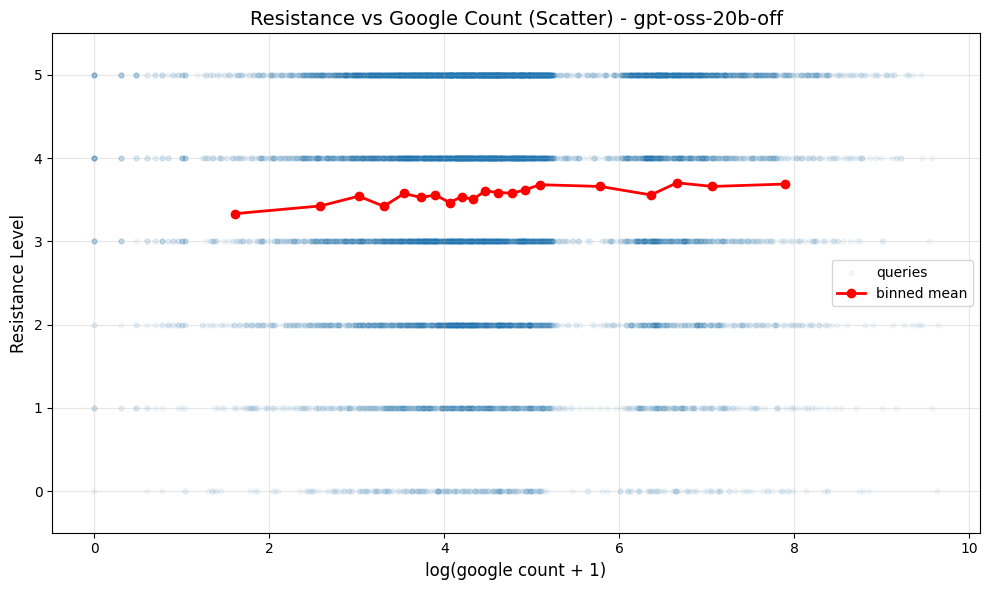


Binned summary (median google count, mean resistance):
                   median_gc  mean_resistance
gc_bin                                       
(0.999, 521.85]           41         3.333973
(521.85, 1042.7]         383         3.426104
(1042.7, 1563.55]       1050         3.543186
(1563.55, 2084.4]       2040         3.422265
(2084.4, 2605.25]       3480         3.575816
(2605.25, 3126.1]       5400         3.527831
(3126.1, 3646.95]       7930         3.557692
(3646.95, 4167.8]      11500         3.466411
(4167.8, 4688.65]      15800         3.537428
(4688.65, 5209.5]      21300         3.504798


In [17]:
# Resistance vs Google count (scatter + binned line)
possible_cols = ['google_count', 'google_hits', 'google_results', 'google_count_total', 'google']
gc_col = next((c for c in possible_cols if c in dataset.columns), None)
if gc_col is None:
    print('No google-count column found. Available columns:')
    print(list(dataset.columns))
else:
    df_res = dataset.copy()
    df_res[gc_col] = dataset[gc_col].fillna(0).astype(float).values
    df_res['log_gc'] = np.log10(df_res[gc_col] + 1)

    # Binned means (quantile bins)
    try:
        n_bins = 20
        uniq = df_res[gc_col].nunique()
        n_bins = min(n_bins, uniq)
        df_res['gc_bin'] = pd.qcut(df_res[gc_col].rank(method='first'), q=n_bins, duplicates='drop')
        bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))
        bin_stats = bin_stats.dropna()
        bin_x = np.log10(bin_stats['median_gc'].values)
        bin_y = bin_stats['mean_resistance'].values
    except Exception as e:
        print('Binning failed:', e)
        bin_x, bin_y = None, None

    # Scatter + binned line
    plt.figure(figsize=(10, 6))
    plt.scatter(df_res['log_gc'], df_res['resistance'], alpha=0.05, s=12, label='queries')
    if bin_x is not None:
        plt.plot(bin_x, bin_y, color='red', marker='o', linewidth=2, label='binned mean')
    plt.xlabel('log(google count + 1)', fontsize=12)
    plt.ylabel('Resistance Level', fontsize=12)
    plt.title(f'Resistance vs Google Count (Scatter) - {model}', fontsize=14)
    plt.ylim(-0.5, 5.5)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print simple bin summary
    if bin_x is not None:
        summary = bin_stats.copy()
        summary['median_gc'] = summary['median_gc'].astype(int)
        print('\nBinned summary (median google count, mean resistance):')
        print(summary[['median_gc', 'mean_resistance']].head(10).to_string())


C:\Users\vsros\AppData\Local\Temp\ipykernel_34932\3407223836.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))


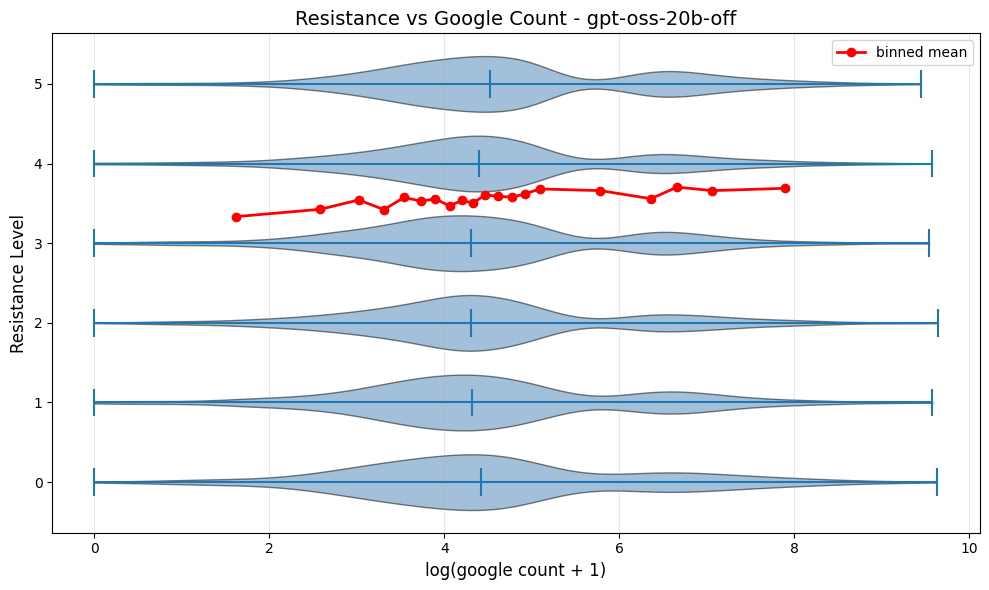


Binned summary (median google count, mean resistance):
                   median_gc  mean_resistance
gc_bin                                       
(0.999, 521.85]           41         3.333973
(521.85, 1042.7]         383         3.426104
(1042.7, 1563.55]       1050         3.543186
(1563.55, 2084.4]       2040         3.422265
(2084.4, 2605.25]       3480         3.575816
(2605.25, 3126.1]       5400         3.527831
(3126.1, 3646.95]       7930         3.557692
(3646.95, 4167.8]      11500         3.466411
(4167.8, 4688.65]      15800         3.537428
(4688.65, 5209.5]      21300         3.504798


In [18]:
# Resistance vs Google count (violin plot + binned line)
# Horizontal violin plot showing distribution of google counts at each resistance level
possible_cols = ['google_count', 'google_hits', 'google_results', 'google_count_total', 'google']
gc_col = next((c for c in possible_cols if c in dataset.columns), None)
if gc_col is None:
    print('No google-count column found. Available columns:')
    print(list(dataset.columns))
else:
    df_res = dataset.copy()
    df_res[gc_col] = dataset[gc_col].fillna(0).astype(float).values
    df_res['log_gc'] = np.log10(df_res[gc_col] + 1)

    # Calculate binned means for overlay line
    try:
        n_bins = 20
        uniq = df_res[gc_col].nunique()
        n_bins = min(n_bins, uniq)
        df_res['gc_bin'] = pd.qcut(df_res[gc_col].rank(method='first'), q=n_bins, duplicates='drop')
        bin_stats = df_res.groupby('gc_bin').agg(median_gc=(gc_col, 'median'), mean_resistance=('resistance', 'mean'))
        bin_stats = bin_stats.dropna()
        bin_x = np.log10(bin_stats['median_gc'].values + 1)
        bin_y = bin_stats['mean_resistance'].values
    except Exception as e:
        print('Binning failed:', e)
        bin_x, bin_y = None, None

    # Create violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for violin plot (resistance as categorical)
    parts = ax.violinplot(
        [df_res[df_res['resistance'] == r]['log_gc'].values for r in range(6)],
        positions=range(6),
        vert=False,
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )
    
    # Style the violins
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.5)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # Overlay binned mean line
    if bin_x is not None:
        ax.plot(bin_x, bin_y, color='red', marker='o', linewidth=2, markersize=6, label='binned mean', zorder=10)
    
    ax.set_ylabel('Resistance Level', fontsize=12)
    ax.set_xlabel('log(google count + 1)', fontsize=12)
    ax.set_title(f'Resistance vs Google Count - {model}', fontsize=14)
    ax.set_yticks(range(6))
    ax.grid(alpha=0.3, axis='x')
    if bin_x is not None:
        ax.legend()
    plt.tight_layout()
    plt.show()

    # Print simple bin summary
    if bin_x is not None:
        summary = bin_stats.copy()
        summary['median_gc'] = summary['median_gc'].astype(int)
        print('\nBinned summary (median google count, mean resistance):')
        print(summary[['median_gc', 'mean_resistance']].head(10).to_string())

C:\Users\vsros\AppData\Local\Temp\ipykernel_34932\3791323562.py:23: RuntimeWarning: divide by zero encountered in log10
  'log_gc': np.log10(gc) if pd.notna(gc) else 0
C:\Users\vsros\AppData\Local\Temp\ipykernel_34932\3791323562.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_all.groupby('gc_bin').agg(


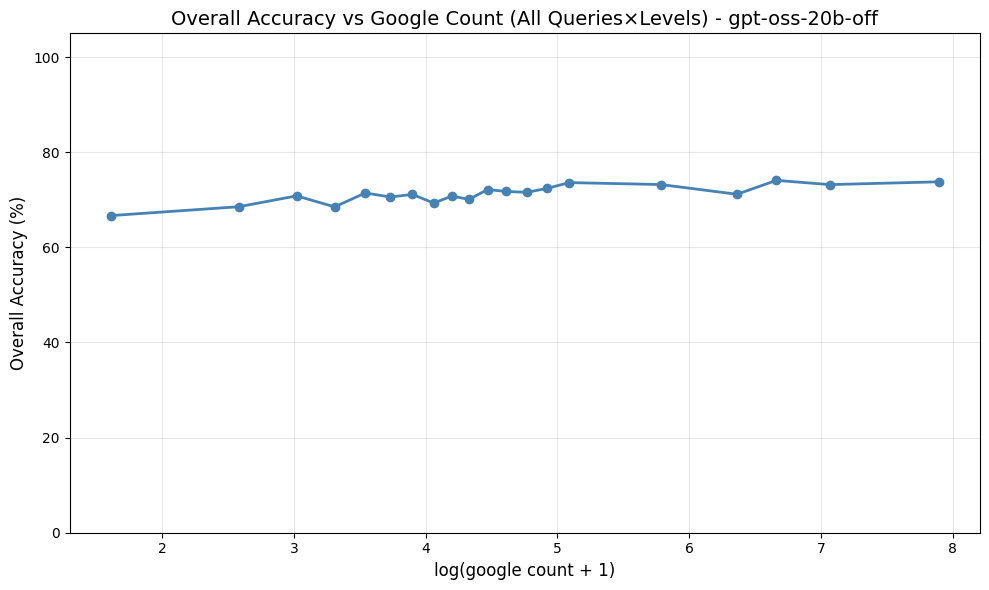


Total data points (queries × levels): 52090
Overall accuracy: 71.24%

Binned summary (median google count, mean accuracy%):
                     median_gc  mean_accuracy_pct
gc_bin                                           
(0.999, 2605.45]            41          66.679463
(2605.45, 5209.9]          383          68.548387
(5209.9, 7814.35]         1050          70.825336
(7814.35, 10418.8]        2040          68.509985
(10418.8, 13023.25]       3480          71.439539
(13023.25, 15627.7]       5400          70.583717
(15627.7, 18232.15]       7930          71.132438
(18232.15, 20836.6]      11500          69.316436
(20836.6, 23441.05]      15800          70.786948
(23441.05, 26045.5]      21300          70.084485


In [19]:
# Overall accuracy vs Google count (binned line plot)
# Accuracy calculated across ALL queries at ALL levels (not per-claim average)
# Each data point = one query at one presupposition level
possible_cols = ['google_count', 'google_hits', 'google_results', 'google_count_total', 'google']
gc_col = next((c for c in possible_cols if c in dataset.columns), None)
if gc_col is None:
    print('No google-count column found. Available columns:')
    print(list(dataset.columns))
else:
    # Create a dataframe with one row per query-level combination
    query_level_data = []
    for idx, row in dataset.iterrows():
        base_id = row['id']
        label = row['label']
        gc = row[gc_col]
        
        # Get accuracy for each presupposition level (0-4)
        for lvl in range(5):
            is_acc = accurate_arr[idx, lvl]
            query_level_data.append({
                'google_count': gc,
                'is_accurate': int(is_acc),
                'log_gc': np.log10(gc) if pd.notna(gc) else 0
            })
    
    df_all = pd.DataFrame(query_level_data)
    df_all['google_count'] = df_all['google_count'].fillna(0).astype(float)
    
    # Binned means (quantile bins on google count)
    try:
        n_bins = 20
        uniq = df_all['google_count'].nunique()
        n_bins = min(n_bins, uniq)
        df_all['gc_bin'] = pd.qcut(df_all['google_count'].rank(method='first'), q=n_bins, duplicates='drop')
        bin_stats = df_all.groupby('gc_bin').agg(
            median_gc=('google_count', 'median'), 
            mean_accuracy=('is_accurate', 'mean')
        )
        bin_stats = bin_stats.dropna()
        bin_stats['mean_accuracy_pct'] = bin_stats['mean_accuracy'] * 100
        
        bin_x = np.log10(bin_stats['median_gc'].values)
        bin_y = bin_stats['mean_accuracy_pct'].values
        
        plt.figure(figsize=(10, 6))
        plt.plot(bin_x, bin_y, color='steelblue', marker='o', linewidth=2, markersize=6)
        plt.xlabel('log(google count + 1)', fontsize=12)
        plt.ylabel('Overall Accuracy (%)', fontsize=12)
        plt.title(f'Overall Accuracy vs Google Count (All Queries×Levels) - {model}', fontsize=14)
        plt.ylim(0, 105)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Print bin summary
        summary = bin_stats.copy()
        summary['median_gc'] = summary['median_gc'].astype(int)
        print(f'\nTotal data points (queries × levels): {len(df_all)}')
        print(f'Overall accuracy: {df_all["is_accurate"].mean() * 100:.2f}%')
        print('\nBinned summary (median google count, mean accuracy%):')
        print(summary[['median_gc', 'mean_accuracy_pct']].head(10).to_string())
    except Exception as e:
        print('Binning failed:', e)